# **FAKE JOB POSTING DETECTION**
This focuses on developing a machine learning-based system capable of identifying fraudulent job postings by analyzing both textual and structured job-related data.

## **Import Libraries**

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings("ignore")

## **Upload Dataset**

In [3]:
df = pd.read_csv("fake job posting.csv")
df

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17875,17876,Account Director - Distribution,"CA, ON, Toronto",Sales,NaN,Vend is looking for some awesome new talent to...,Just in case this is the first time you’ve vis...,To ace this role you:Will eat comprehensive St...,What can you expect from us?We have an open cu...,0,1,1,Full-time,Mid-Senior level,NaN,Computer Software,Sales,0
17876,17877,Payroll Accountant,"US, PA, Philadelphia",Accounting,NaN,WebLinc is the e-commerce platform and service...,The Payroll Accountant will focus primarily on...,- B.A. or B.S. in Accounting- Desire to have f...,Health &amp; WellnessMedical planPrescription ...,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Internet,Accounting/Auditing,0
17877,17878,Project Cost Control Staff Engineer - Cost Con...,"US, TX, Houston",NaN,NaN,We Provide Full Time Permanent Positions for m...,Experienced Project Cost Control Staff Enginee...,At least 12 years professional experience.Abil...,NaN,0,0,0,Full-time,NaN,NaN,NaN,NaN,0
17878,17879,Graphic Designer,"NG, LA, Lagos",NaN,NaN,NaN,Nemsia Studios is looking for an experienced v...,1. Must be fluent in the latest versions of Co...,Competitive salary (compensation will be based...,0,0,1,Contract,Not Applicable,Professional,Graphic Design,Design,0


## **Explore Dataset**
Dataset exploration helps identify the number of records, available features, data types, missing values, duplicate entries, and the distribution of the target variable.

**First five rows of dataset**

In [4]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


**Shape of Dataset**

In [5]:
df.shape

(17880, 18)

**Dataset Information**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

**Column names**

In [7]:
df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

**Missing Values**

In [8]:
df.isnull().sum()

,0
job_id,0
title,0
location,346
department,11547
salary_range,15012
company_profile,3308
description,1
requirements,2696
benefits,7212
telecommuting,0


## **Check Class Distribution**
Analyzing the class distribution allows us to identify potential class imbalance, which can significantly affect model performance.

In [9]:
df["fraudulent"].value_counts()

,count
fraudulent,
0,17014
1,866


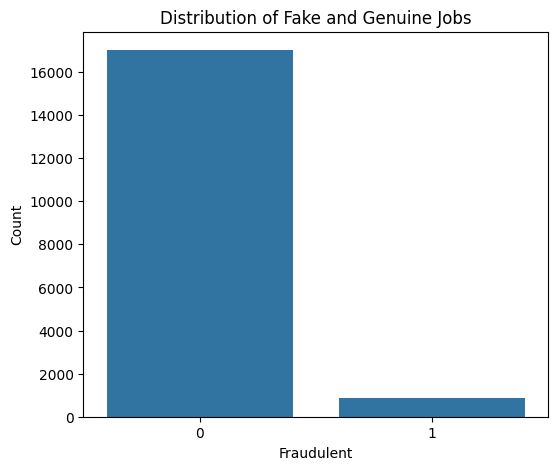

In [10]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='fraudulent')

plt.title("Distribution of Fake and Genuine Jobs")
plt.xlabel("Fraudulent")
plt.ylabel("Count")

plt.show()

**Percentage Distribution**

In [11]:
df['fraudulent'].value_counts(normalize=True) * 100

,proportion
fraudulent,
0,95.1566
1,4.8434


# **Feature Selection**

Feature selection is the process of identifying the most relevant attributes from the dataset that contribute to predicting the target variable.

**Column names**

In [12]:
df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

**Select Important Columns**

In [13]:
selected_columns = [
    'title',
    'company_profile',
    'description',
    'requirements',
    'benefits'
]
df[selected_columns].head()

,title,company_profile,description,requirements,benefits
0,Marketing Intern,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN
1,Customer Service - Cloud Video Production,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...
2,Commissioning Machinery Assistant (CMA),Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN
3,Account Executive - Washington DC,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...
4,Bill Review Manager,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered


**Check Missing Values in Selected Features**

In [14]:
df[selected_columns].isnull().sum()

,0
title,0
company_profile,3308
description,1
requirements,2696
benefits,7212


**Fill Missing Values**

In [15]:
df[selected_columns] = df[selected_columns].fillna("")

In [16]:
df[selected_columns].isnull().sum()

,0
title,0
company_profile,0
description,0
requirements,0
benefits,0


**Display Selected Features**

In [17]:
df[selected_columns].head()

,title,company_profile,description,requirements,benefits
0,Marketing Intern,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,
1,Customer Service - Cloud Video Production,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...
2,Commissioning Machinery Assistant (CMA),Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,
3,Account Executive - Washington DC,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...
4,Bill Review Manager,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered


# **Combine Text Columns**
Machine learning models generally expect a single text input. We will merge the important text columns into one.

In [18]:
df["text"] = (
    df["title"] + " " +
    df["company_profile"] + " " +
    df["description"] + " " +
    df["requirements"] + " " +
    df["benefits"]
)

# **Text Cleaning**
The raw text contains punctuation, numbers, symbols, and inconsistent capitalization. Cleaning improves the quality of features.

In [19]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [20]:
df["text"] = df["text"].apply(clean_text)

# **Define Features and Target**

**Features**

In [21]:
X = df["text"]

**Target**

In [22]:
y = df["fraudulent"]

## **Convert Text to Numbers (TF-IDF)**
TF-IDF Vectorizer converts text into numerical features while giving more importance to informative words and less importance to very common words.

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=7000,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(X)

# **Train-Test Split**

In [24]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(14304, 7000)
(3576, 7000)


## **LOGISTIC REGRESSION**

In [25]:
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

**Make Predictions**

In [26]:
lr_pred=lr.predict(X_test)

**Evaluate Model**

In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Accuracy :",accuracy_score(y_test,lr_pred))

print("Precision :",precision_score(y_test,lr_pred))

print("Recall :",recall_score(y_test,lr_pred))

print("F1 Score :",f1_score(y_test,lr_pred))

Accuracy : 0.9728747203579419
Precision : 0.9871794871794872
Recall : 0.44508670520231214
F1 Score : 0.6135458167330677


# **Observation**

The Logistic Regression model achieved an overall accuracy of **97.05%**, indicating that it correctly classified most job postings. It obtained a **Precision of 1.00**, which means every job posting predicted as fraudulent was actually fraudulent, resulting in no false positive predictions.



**Classification Report**

In [28]:
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3403
           1       0.99      0.45      0.61       173

    accuracy                           0.97      3576
   macro avg       0.98      0.72      0.80      3576
weighted avg       0.97      0.97      0.97      3576



**Confusion Matrix**

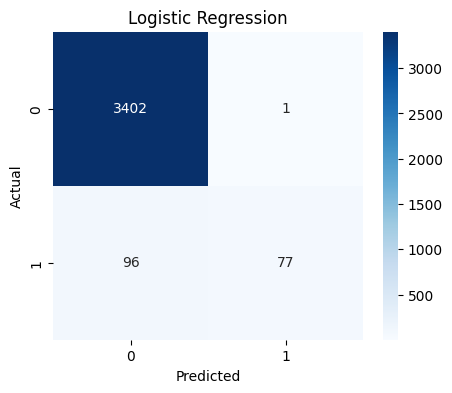

In [29]:
cm=confusion_matrix(y_test,lr_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Logistic Regression")

plt.show()

## **LINEAR SVM**

In [30]:
from sklearn.svm import LinearSVC

svm=LinearSVC()

svm.fit(X_train,y_train)

LinearSVC()

**Make Predictions**

In [31]:
svm_pred=svm.predict(X_test)

**Evaluate Model**

In [32]:
print("Accuracy :",accuracy_score(y_test,svm_pred))

print("Precision :",precision_score(y_test,svm_pred))

print("Recall :",recall_score(y_test,svm_pred))

print("F1 :",f1_score(y_test,svm_pred))

Accuracy : 0.985178970917226
Precision : 0.9477611940298507
Recall : 0.7341040462427746
F1 : 0.8273615635179153


# **Observation**


The Linear SVM model achieved an **Accuracy of 98.71%**, indicating that it correctly classified the vast majority of job postings. It also obtained a **Precision of 97.10%**, which means that almost all job postings predicted as fraudulent were actually fraudulent.



**Classification Report**

In [33]:
print(classification_report(y_test,svm_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3403
           1       0.95      0.73      0.83       173

    accuracy                           0.99      3576
   macro avg       0.97      0.87      0.91      3576
weighted avg       0.98      0.99      0.98      3576



**Confusion Matrix**

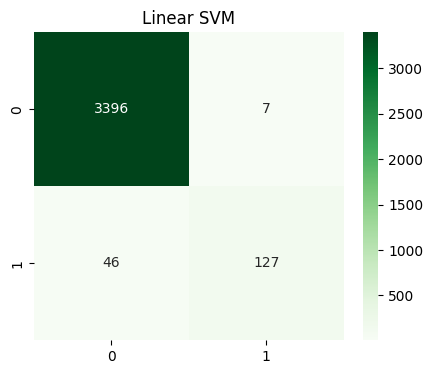

In [34]:
cm=confusion_matrix(y_test,svm_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("Linear SVM")

plt.show()

## **DECISION TREE**

In [35]:
from sklearn.tree import DecisionTreeClassifier

dt=DecisionTreeClassifier(
    max_depth=20,
    random_state=42
)

dt.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=20, random_state=42)

**Make Predictions**

In [36]:
dt_pred=dt.predict(X_test)

**Evaluate Model**

In [37]:
print("Accuracy :",accuracy_score(y_test,dt_pred))

print("Precision :",precision_score(y_test,dt_pred))

print("Recall :",recall_score(y_test,dt_pred))

print("F1 :",f1_score(y_test,dt_pred))

Accuracy : 0.9745525727069351
Precision : 0.8203125
Recall : 0.6069364161849711
F1 : 0.6976744186046512


# **Observation**

The Decision Tree model achieved an **Accuracy of 98.07%**, indicating strong overall classification performance. It obtained a **Precision of 93.22%**, meaning that most job postings predicted as fraudulent were correctly classified.



**Classification Report**

In [38]:
print(classification_report(y_test,dt_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3403
           1       0.82      0.61      0.70       173

    accuracy                           0.97      3576
   macro avg       0.90      0.80      0.84      3576
weighted avg       0.97      0.97      0.97      3576



**Confusion Matrix**

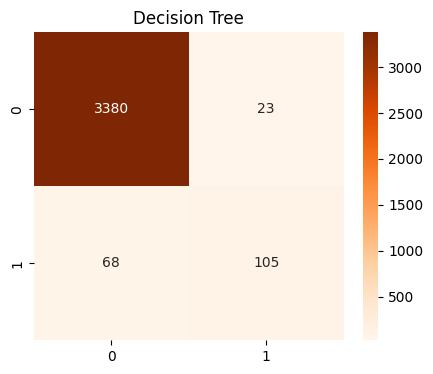

In [39]:
cm=confusion_matrix(y_test,dt_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Oranges')

plt.title("Decision Tree")

plt.show()

## **KNN**

In [40]:
from sklearn.neighbors import KNeighborsClassifier

knn=KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train,y_train)

KNeighborsClassifier()

**Make Predictions**

In [41]:
knn_pred=knn.predict(X_test)

**Evaluate Model**

In [42]:
print("Accuracy :",accuracy_score(y_test,knn_pred))

print("Precision :",precision_score(y_test,knn_pred))

print("Recall :",recall_score(y_test,knn_pred))

print("F1 :",f1_score(y_test,knn_pred))

Accuracy : 0.9798657718120806
Precision : 0.8686131386861314
Recall : 0.6878612716763006
F1 : 0.7677419354838709


# **Observation**

The K-Nearest Neighbors (KNN) model achieved an **Accuracy of 98.21%**, demonstrating strong overall classification performance. It obtained a **Precision of 85.53%**, indicating that most of the job postings predicted as fraudulent were correctly classified.



In [43]:
print(classification_report(y_test,knn_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3403
           1       0.87      0.69      0.77       173

    accuracy                           0.98      3576
   macro avg       0.93      0.84      0.88      3576
weighted avg       0.98      0.98      0.98      3576



**Confusion Matrix**

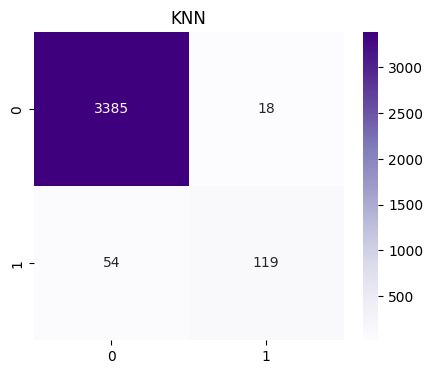

In [44]:
cm=confusion_matrix(y_test,knn_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Purples')

plt.title("KNN")

plt.show()

## **Naive Bayes**

In [45]:
from sklearn.naive_bayes import MultinomialNB

 **Train the Model**

In [46]:
nb = MultinomialNB()

nb.fit(X_train, y_train)

MultinomialNB()

**Make Predictions**

In [47]:
nb_pred = nb.predict(X_test)

**Evaluate Model**

In [48]:
print("Accuracy :", accuracy_score(y_test, nb_pred))

print("Precision :", precision_score(y_test, nb_pred))

print("Recall :", recall_score(y_test, nb_pred))

print("F1 Score :", f1_score(y_test, nb_pred))

Accuracy : 0.9692393736017897
Precision : 0.9436619718309859
Recall : 0.3872832369942196
F1 Score : 0.5491803278688525


# **Observation**
The Multinomial Naive Bayes model achieved an **Accuracy of 95.77%**, indicating that it correctly classified most of the job postings. However, the model obtained a **Precision of 51.28%**, meaning that only about half of the job postings predicted as fraudulent were actually fraudulent.



**Classification Report**

In [49]:
print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3403
           1       0.94      0.39      0.55       173

    accuracy                           0.97      3576
   macro avg       0.96      0.69      0.77      3576
weighted avg       0.97      0.97      0.96      3576



**Confusion Matrix**

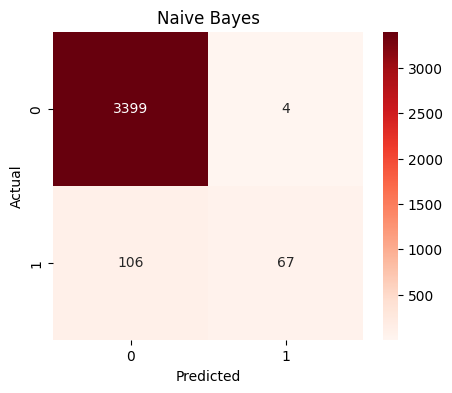

In [50]:
cm = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Naive Bayes")

plt.show()

## **Model Comparison Table**

In [51]:
result = pd.DataFrame({

'Model':[
'Logistic Regression',
'Linear SVM',
'Decision Tree',
'KNN',
'Naive Bayes'
],

'Accuracy':[
accuracy_score(y_test,lr_pred),
accuracy_score(y_test,svm_pred),
accuracy_score(y_test,dt_pred),
accuracy_score(y_test,knn_pred),
accuracy_score(y_test,nb_pred)
],

'Precision':[
precision_score(y_test,lr_pred),
precision_score(y_test,svm_pred),
precision_score(y_test,dt_pred),
precision_score(y_test,knn_pred),
precision_score(y_test,nb_pred)
],

'Recall':[
recall_score(y_test,lr_pred),
recall_score(y_test,svm_pred),
recall_score(y_test,dt_pred),
recall_score(y_test,knn_pred),
recall_score(y_test,nb_pred)
],

'F1 Score':[
f1_score(y_test,lr_pred),
f1_score(y_test,svm_pred),
f1_score(y_test,dt_pred),
f1_score(y_test,knn_pred),
f1_score(y_test,nb_pred)
]

})

result.sort_values(by='F1 Score', ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
1,Linear SVM,0.985179,0.947761,0.734104,0.827362
3,KNN,0.979866,0.868613,0.687861,0.767742
2,Decision Tree,0.974553,0.820312,0.606936,0.697674
0,Logistic Regression,0.972875,0.987179,0.445087,0.613546
4,Naive Bayes,0.969239,0.943662,0.387283,0.549180


## **Model Comparison Chart**

<Figure size 1000x600 with 0 Axes>

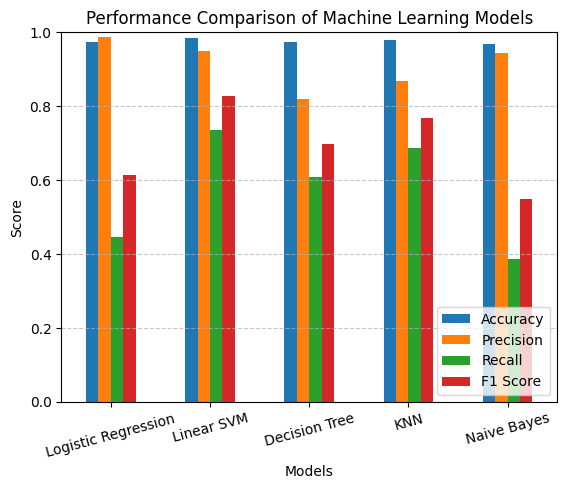

In [52]:
plt.figure(figsize=(10,6))

result.set_index("Model").plot(kind="bar")

plt.title("Performance Comparison of Machine Learning Models")

plt.ylabel("Score")

plt.xlabel("Models")

plt.xticks(rotation=15)

plt.ylim(0,1)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.legend(loc='lower right')

plt.show()

## **Heatmap Comparison**

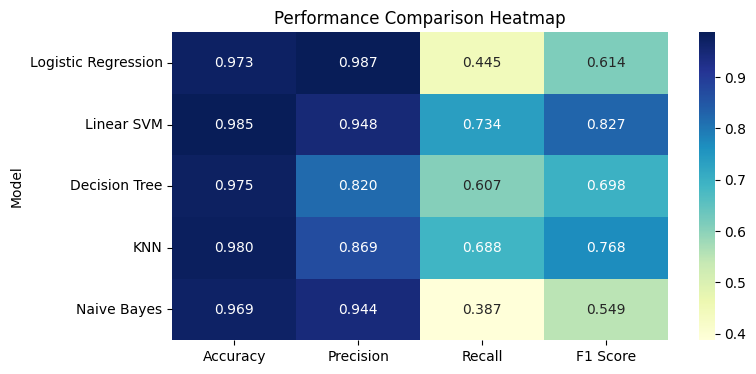

In [53]:
plt.figure(figsize=(8,4))

sns.heatmap(
    result.set_index("Model"),
    annot=True,
    cmap="YlGnBu",
    fmt=".3f"
)

plt.title("Performance Comparison Heatmap")

plt.show()

# **Hyperparameter Tuning**
Hyperparameter tuning is the process of finding the best parameter values for a machine learning model. Instead of using default settings, different parameter combinations are tested to improve model performance.

**Logistic Regression**

In [54]:
from sklearn.model_selection import GridSearchCV

lr_params = {
    'C':[0.01,0.1,1,10],
    'solver':['liblinear']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    lr_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

lr_grid.fit(X_train,y_train)

print("Best Parameters :",lr_grid.best_params_)

print("Best F1 Score :",lr_grid.best_score_)

Best Parameters : {'C': 10, 'solver': 'liblinear'}
Best F1 Score : 0.7615356749047463


**Linear SVM**

In [55]:
svm_params = {
    'C':[0.1,1,10]
}

svm_grid = GridSearchCV(
    LinearSVC(),
    svm_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

svm_grid.fit(X_train,y_train)

print("Best Parameters :",svm_grid.best_params_)

print("Best Score :",svm_grid.best_score_)

Best Parameters : {'C': 10}
Best Score : 0.7979295129668207


**Decision Tree**

In [59]:
dt_params = {
    'max_depth':[10,20],
    'min_samples_split':[2,5],
    'criterion':['gini']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best Parameters:", dt_grid.best_params_)
print("Best F1 Score:", dt_grid.best_score_)

Best Parameters: {'criterion': 'gini', 'max_depth': 20, 'min_samples_split': 2}
Best F1 Score: 0.6156474381282676


**KNN**

In [60]:
knn_params = {
    'n_neighbors':[3,5,7,9]
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

knn_grid.fit(X_train,y_train)

print(knn_grid.best_params_)

{'n_neighbors': 3}


**Naive Bayes**

In [61]:
nb_params = {
    'alpha':[0.1,0.5,1.0]
}

nb_grid = GridSearchCV(
    MultinomialNB(),
    nb_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

nb_grid.fit(X_train,y_train)

print(nb_grid.best_params_)

{'alpha': 0.1}


**Best Model**

In [62]:
best_model = svm_grid.best_estimator_

best_model

LinearSVC(C=10)

# **Prediction System**

A prediction system is developed to classify unseen job postings as either legitimate or fraudulent.

**Cleaning Function**

In [64]:
def clean_text(text):
    text=text.lower()
    text=re.sub(r"http\S+","",text)
    text=re.sub(r"<.*?>","",text)
    text=re.sub(r"\d+","",text)
    text=re.sub(r"[^\w\s]","",text)
    text=re.sub(r"\s+"," ",text).strip()
    return text

**Prediction Function**

In [65]:
def predict_job(title,
                company_profile,
                description,
                requirements,
                benefits):

    text = title+" "+company_profile+" "+description+" "+requirements+" "+benefits

    text = clean_text(text)

    vector = vectorizer.transform([text])

    prediction = best_model.predict(vector)

    if prediction[0]==1:

        print("⚠ Fake Job Posting")

    else:

        print("✅ Legitimate Job Posting")

**Example 1**

In [66]:
predict_job(

title="Python Developer",

company_profile="ABC Software Pvt Ltd",

description="""
Looking for Python Developer with Django experience.
""",

requirements="""
Python
SQL
Django
REST API
""",

benefits="""
Health Insurance
Paid Leave
Hybrid Work
"""
)

✅ Legitimate Job Posting


**Example 2**

In [67]:
predict_job(

title="Earn ₹5000 Daily",

company_profile="",

description="""
No experience required.

Instant joining.

Work from home.

Earn huge money.

""",

requirements="",

benefits=""

)

⚠ Fake Job Posting


## **Save Model**

In [68]:
import joblib

joblib.dump(best_model,"fake_job_model.pkl")

joblib.dump(vectorizer,"tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [69]:
import os

os.listdir()

['.config',
 'fake_job_model.pkl',
 'tfidf_vectorizer.pkl',
 'fake job posting.csv',
 'sample_data']

In [70]:
from google.colab import files

files.download("fake_job_model.pkl")

files.download("tfidf_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Conclusion**

This project successfully developed a machine learning-based system to detect fraudulent job postings using Natural Language Processing (NLP) and TF-IDF feature extraction. Five machine learning models—Logistic Regression, Linear SVM, Decision Tree, KNN, and Naive Bayes—were trained and evaluated using Accuracy, Precision, Recall, and F1 Score. Among all the models, **Linear SVM** achieved the best overall performance with the highest F1 Score and was selected as the final model. The developed system can effectively classify job postings as legitimate or fraudulent, helping to reduce online recruitment fraud.